In [80]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [81]:
# first we will read the data and check the first few rows
deliveries = pd.read_csv('deliveries.csv')
matches = pd.read_csv('matches.csv')

In [82]:
deliveries.info()
deliveries.describe()
deliveries.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
5,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,6,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
6,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,7,BB McCullum,P Kumar,SC Ganguly,0,1,1,legbyes,0,NaN,NaN,NaN
7,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,1,1,BB McCullum,Z Khan,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
8,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,1,2,BB McCullum,Z Khan,SC Ganguly,4,0,4,NaN,0,NaN,NaN,NaN
9,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,1,3,BB McCullum,Z Khan,SC Ganguly,4,0,4,NaN,0,NaN,NaN,NaN


In [83]:
matches.info()
matches.describe()
matches.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan
5,335987,2007/08,Jaipur,2008-04-21,League,SR Watson,Sawai Mansingh Stadium,Rajasthan Royals,Kings XI Punjab,Kings XI Punjab,bat,Rajasthan Royals,wickets,6.0,167.0,20.0,N,NaN,Aleem Dar,RB Tiffin
6,335988,2007/08,Hyderabad,2008-04-22,League,V Sehwag,"Rajiv Gandhi International Stadium, Uppal",Deccan Chargers,Delhi Daredevils,Deccan Chargers,bat,Delhi Daredevils,wickets,9.0,143.0,20.0,N,NaN,IL Howell,AM Saheba
7,335989,2007/08,Chennai,2008-04-23,League,ML Hayden,"MA Chidambaram Stadium, Chepauk",Chennai Super Kings,Mumbai Indians,Mumbai Indians,field,Chennai Super Kings,runs,6.0,209.0,20.0,N,NaN,DJ Harper,GA Pratapkumar
8,335990,2007/08,Hyderabad,2008-04-24,League,YK Pathan,"Rajiv Gandhi International Stadium, Uppal",Deccan Chargers,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,3.0,215.0,20.0,N,NaN,Asad Rauf,MR Benson
9,335991,2007/08,Chandigarh,2008-04-25,League,KC Sangakkara,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Mumbai Indians,Mumbai Indians,field,Kings XI Punjab,runs,66.0,183.0,20.0,N,NaN,Aleem Dar,AM Saheba


## Step2:- Cleaning the data

In [84]:
# Q1. How many missing values are in each column of matches?
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [85]:
# Q2. Drop rows where winner is missing from matches
matches.dropna(subset=['winner'], inplace=True)

In [86]:
# Q3. Check how many unique teams played in IPL
matches['team1'].unique() # It return all name of the unique teams in team1 column
# matches['team1'].unique().size # It return the number of unique teams in team1 column

array(['Royal Challengers Bangalore', 'Kings XI Punjab',
       'Delhi Daredevils', 'Mumbai Indians', 'Kolkata Knight Riders',
       'Rajasthan Royals', 'Deccan Chargers', 'Chennai Super Kings',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Gujarat Lions', 'Rising Pune Supergiants',
       'Rising Pune Supergiant', 'Delhi Capitals', 'Punjab Kings',
       'Lucknow Super Giants', 'Gujarat Titans',
       'Royal Challengers Bengaluru'], dtype=object)

## Now we have an issue in data 
### 'Rising Pune Supergiants'  ← spelling 1
### 'Rising Pune Supergiant'   ← spelling 2 (missing 's'!)

### 'Delhi Daredevils'  ← old name
### 'Delhi Capitals'    ← new name

### 'Kings XI Punjab'   ← old name
### 'Punjab Kings'      ← new name

## so we have to resolve this one first

In [87]:
team_name_mapping = {
    # Spelling variations
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Rising Pune Supergiant': 'Rising Pune Supergiant',  # keep as is
    
    # Team rebranding
    'Delhi Daredevils': 'Delhi Capitals',
    'Delhi Capitals': 'Delhi Capitals',  # keep as is
    
    'Kings XI Punjab': 'Punjab Kings',
    'Punjab Kings': 'Punjab Kings'  # keep as is
}

matches['team1'] = matches['team1'].replace(team_name_mapping)
matches['team2'] = matches['team2'].replace(team_name_mapping)
matches['winner'] = matches['winner'].replace(team_name_mapping)

## 📊 Task 3A — Top 10 Teams by Wins (Bar Chart)

Text(0.5, 1.0, 'Number of Wins by Each Team in IPL')

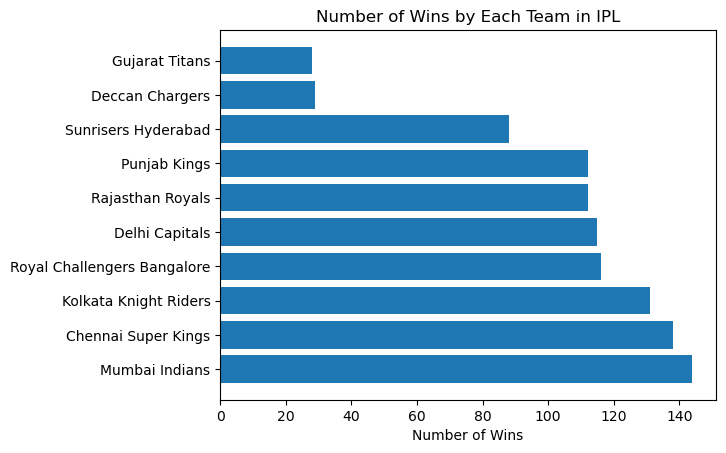

In [88]:
# 📊 Task 3A — Top 10 Teams by Wins (Bar Chart)
win_counts = matches['winner'].value_counts()
top_ten = win_counts.head(10)
# plt.barh(win_counts.index, win_counts.values)
plt.barh(top_ten.index, top_ten.values)
plt.xlabel('Number of Wins')
plt.title('Number of Wins by Each Team in IPL')

## 📊 Task 3B: Toss Win vs Match Win (Bar Chart)

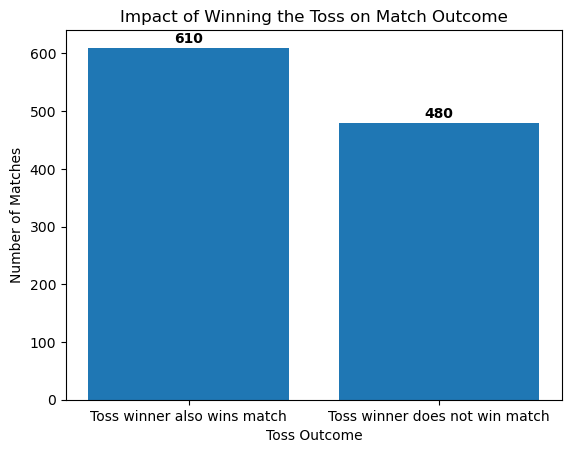

In [89]:
# i will add a new column in matches dataset which indicate the team who win the toss is win the match or not
matches['toss_win_match_win'] = matches['toss_winner'] == matches['winner']
toss_win_counts = matches['toss_win_match_win'].value_counts()
# toss_win_counts
labels = ['Toss winner also wins match', 'Toss winner does not win match']
plt.bar(labels, toss_win_counts.values)
plt.xlabel('Toss Outcome')
plt.ylabel('Number of Matches')
plt.title('Impact of Winning the Toss on Match Outcome')
for index, value in enumerate(toss_win_counts.values):
    plt.text(index, value+3, str(value), ha='center', va='bottom', fontweight='bold')

## 🎯 Task 3C — Line Plot: Season-wise Total Runs

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
 [Text(0, 0, '2007/08'),
  Text(1, 0, '2009'),
  Text(2, 0, '2009/10'),
  Text(3, 0, '2011'),
  Text(4, 0, '2012'),
  Text(5, 0, '2013'),
  Text(6, 0, '2014'),
  Text(7, 0, '2015'),
  Text(8, 0, '2016'),
  Text(9, 0, '2017'),
  Text(10, 0, '2018'),
  Text(11, 0, '2019'),
  Text(12, 0, '2020/21'),
  Text(13, 0, '2021'),
  Text(14, 0, '2022'),
  Text(15, 0, '2023'),
  Text(16, 0, '2024')])

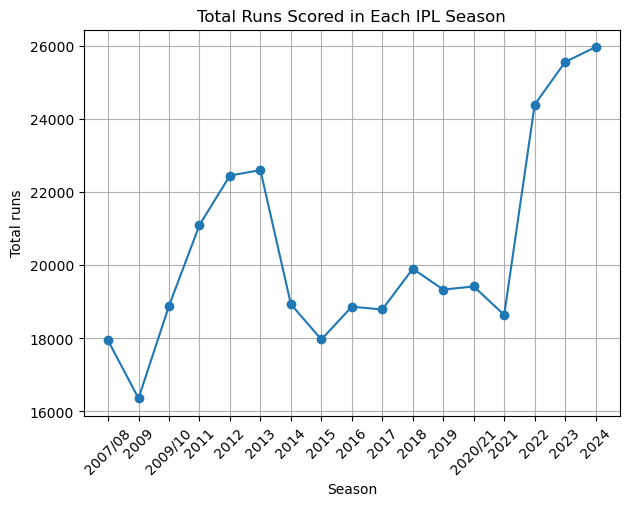

In [90]:
matches.rename(columns={'id': 'match_id'}, inplace=True)
merged_data = pd.merge(deliveries, matches, on='match_id', how='inner')
# merged_data
total_season_runs = merged_data.groupby('season')['total_runs'].sum()
total_season_runs
# plt.plot(total_season_runs.values, total_season_runs.index, marker='o')
plt.plot(total_season_runs.index, total_season_runs.values, marker='o')
plt.xlabel('Season')
plt.ylabel('Total runs')
plt.title('Total Runs Scored in Each IPL Season')
plt.grid(True)       # ❌ missing — line plots look much better with grid
plt.tight_layout()   # ❌ missing
plt.xticks(rotation=45)  # ❌ season labels like "2007/08" will overlap!

## 🎯 Task 4A — Pie Chart: Toss Decision

(np.float64(-1.1251661496515752),
 np.float64(1.0812727767189139),
 np.float64(-1.2016972450093402),
 np.float64(1.1048387691521688))

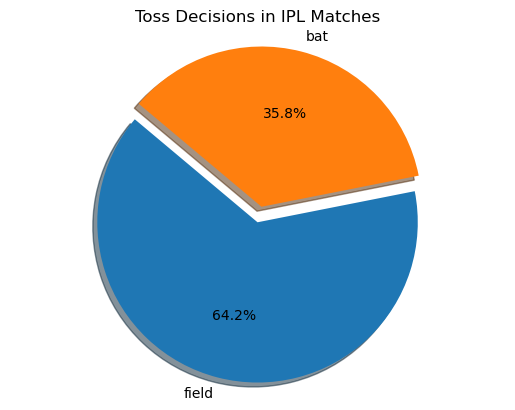

In [ ]:
toss_decision_counts = matches['toss_decision'].value_counts()
toss_decision_counts
labels = toss_decision_counts.index
explode = (0.1, 0)  # explode the first slice (batting)
plt.pie(toss_decision_counts.values, labels=labels, autopct='%1.1f%%', startangle=140, explode=explode, shadow=True)
plt.title('Toss Decisions in IPL Matches')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle

## 🎯 Task 4B — Histogram: Distribution of Win Margins

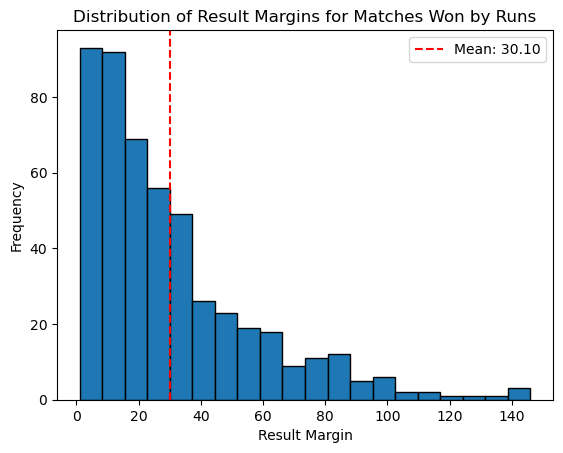

In [92]:
runs_wins = matches[matches['result'] == 'runs']
runs_wins[['team1', 'team2', 'toss_winner', 'winner', 'result', 'result_margin']].head()
plt.hist(runs_wins['result_margin'], bins=20, edgecolor='black')
plt.axvline(runs_wins['result_margin'].mean(), color='red', linestyle='--', label=f'Mean: {runs_wins["result_margin"].mean():.2f}')
# plt.axvline(runs_wins['result_margins].mean(), color='red', linestyle='--', label=f'Mean: {runs_wins['result_margins'].mean():.2f}')
plt.xlabel('Result Margin')
plt.ylabel('Frequency')
plt.title('Distribution of Result Margins for Matches Won by Runs')
plt.legend()

## 🎯 Task 4C — Scatter Plot: Top Run Scorers
Who are the Top 15 batters in IPL history and how many runs did they score? Let's find out using deliveries!

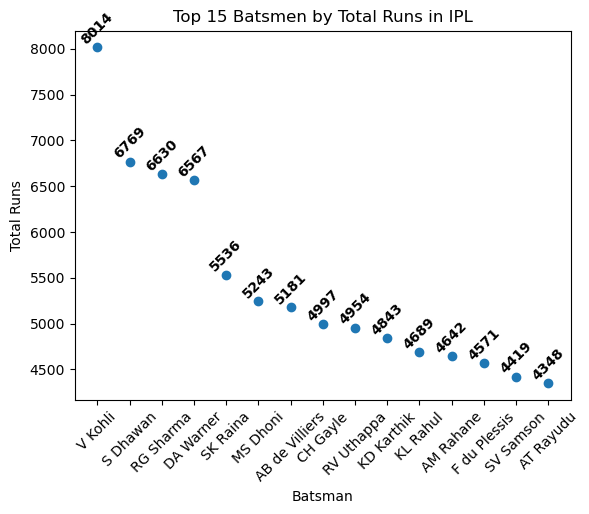

In [93]:
top_batsmen = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(15)
plt.scatter(top_batsmen.index, top_batsmen.values)
plt.ylabel('Total Runs')
plt.xlabel('Batsman')
plt.xticks(rotation=45)
plt.title('Top 15 Batsmen by Total Runs in IPL')
for index, value in enumerate(top_batsmen.values):
    plt.text(index, value+5, str(value), ha='center', va='bottom', fontweight='bold', rotation=45)

## 🎯 Task 5 — Seaborn: Top 10 Bowlers Heatmap
Now we move to Seaborn! Let's find the Top 10 wicket takers and see their wickets season by season as a heatmap!

Index(['YS Chahal', 'DJ Bravo', 'PP Chawla', 'SP Narine', 'R Ashwin',
       'B Kumar', 'SL Malinga', 'A Mishra', 'JJ Bumrah', 'RA Jadeja'],
      dtype='object', name='bowler')


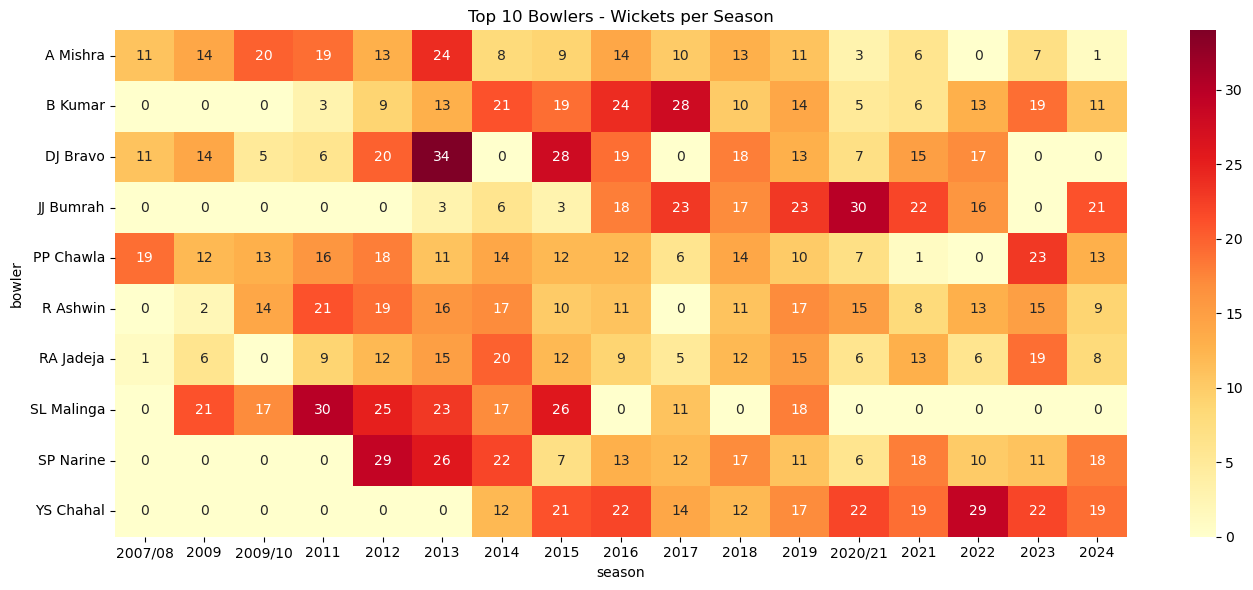

In [94]:
# Step 1 - filter only actual wickets
actual_wickets = deliveries[deliveries['is_wicket'] == 1]

# Step 2 - merge with matches to get season
actual_wickets_merged = pd.merge(actual_wickets, matches[['match_id', 'season']], on='match_id')

# Step 3 - find top 10 bowlers overall
# top_bowlers = actual_wickets_merged.groupby('bowler')['is_wicket'].sum()

# Step 4 - filter only top 10 bowlers
# top_bowlers.sort_values(ascending=False).head(10)

# Step 3 & 4 combined - sort, take top 10, save the NAMES
top_bowlers = actual_wickets_merged.groupby('bowler')['is_wicket'].sum().sort_values(ascending=False).head(10).index
# Verify it worked - should show 10 bowler names
print(top_bowlers)

# Step 5 - filter rows of only top 10 bowlers
top_wickets = actual_wickets_merged[actual_wickets_merged['bowler'].isin(top_bowlers)]

# Step 6 - create pivot table from top_wickets
pivot = top_wickets.pivot_table(index='bowler', columns='season', values='is_wicket', aggfunc='sum').fillna(0)

# Step 7 - plot heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Top 10 Bowlers - Wickets per Season')
plt.tight_layout()
plt.show()

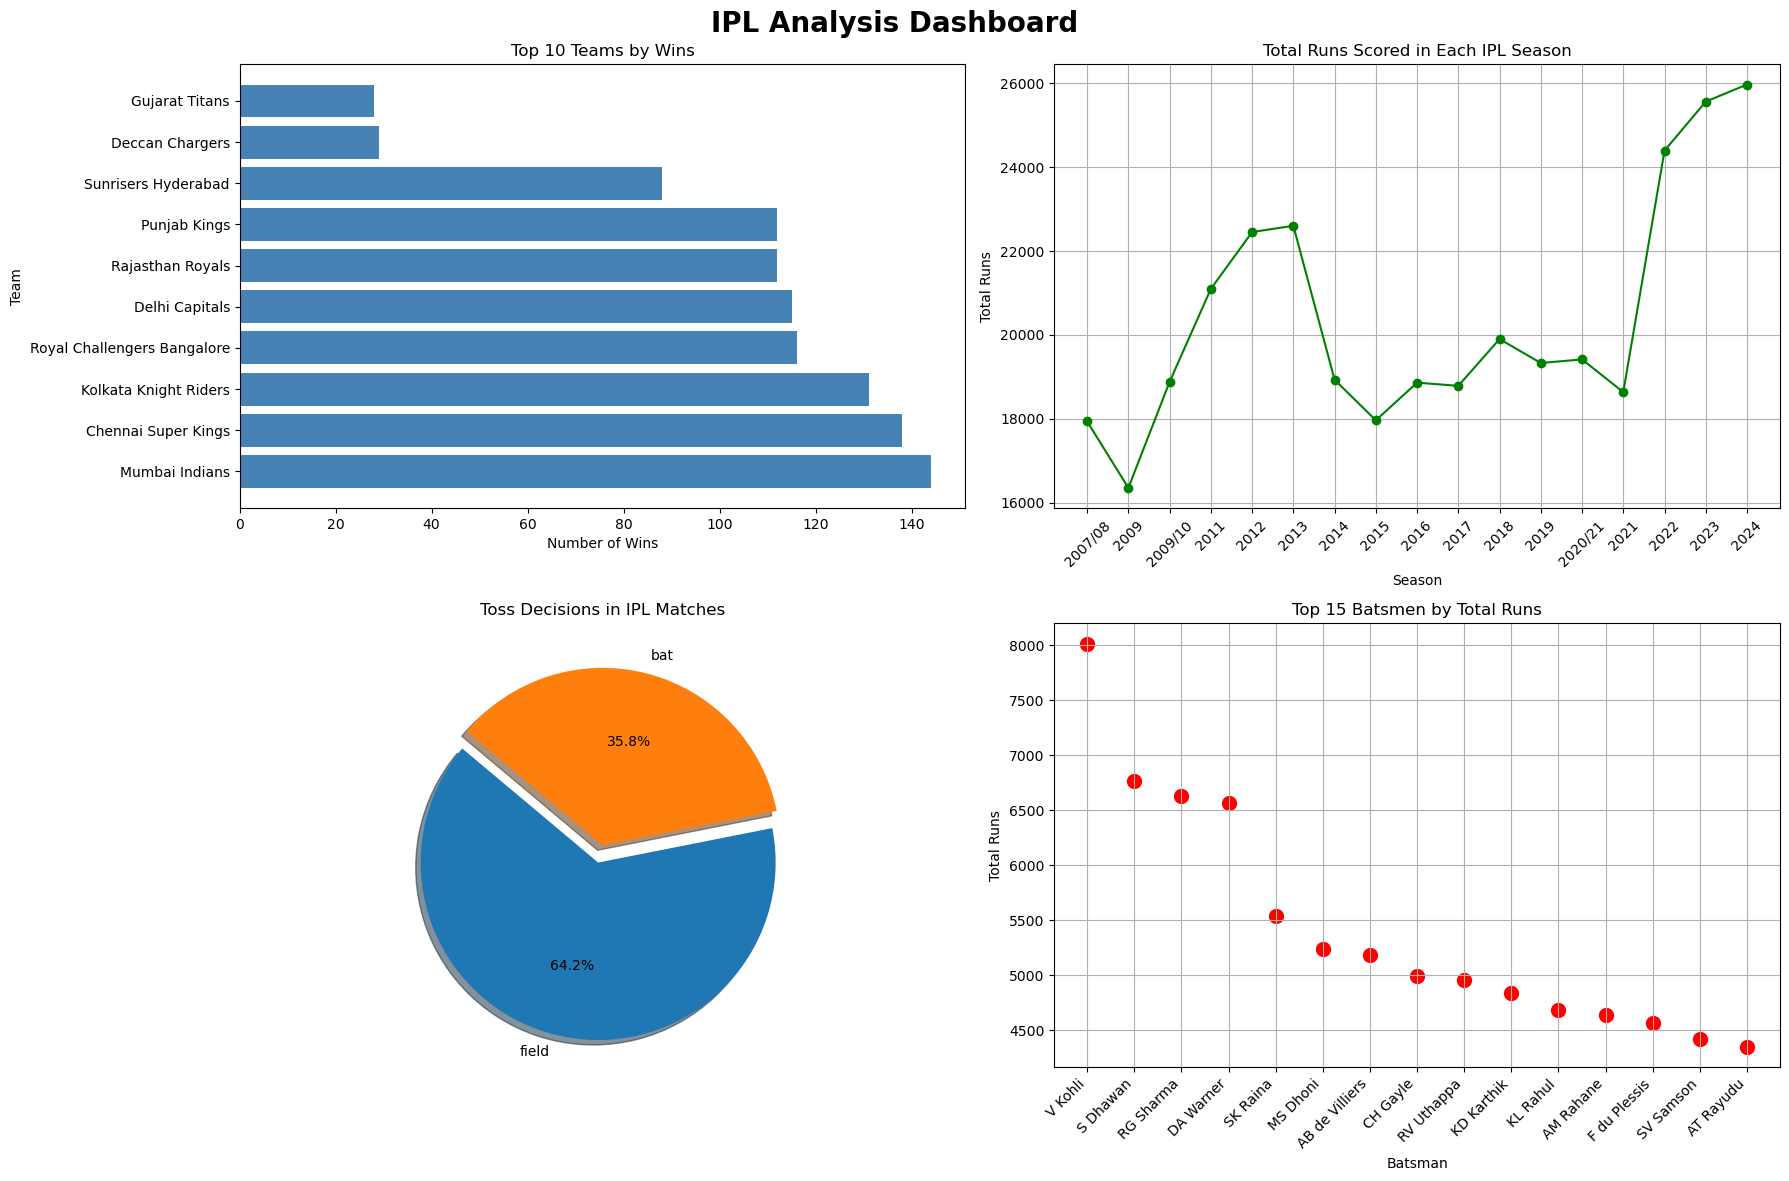

In [101]:
fig, axs = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('IPL Analysis Dashboard', fontsize=20, fontweight='bold')

# PLOT 1 — Top 10 Wins
axs[0, 0].barh(top_ten.index, top_ten.values, color='steelblue')
axs[0, 0].set_xlabel('Number of Wins')
axs[0, 0].set_ylabel('Team')
axs[0, 0].set_title('Top 10 Teams by Wins')

# PLOT 2 — Season wise runs
axs[0, 1].plot(total_season_runs.index, total_season_runs.values, marker='o', color='green')
axs[0, 1].set_xlabel('Season')
axs[0, 1].set_ylabel('Total Runs')
axs[0, 1].set_title('Total Runs Scored in Each IPL Season')
axs[0, 1].grid(True)
axs[0, 1].tick_params(axis='x', rotation=45)  # ✅ fixed!

# PLOT 3 — Toss decision pie
axs[1, 0].pie(toss_decision_counts.values, labels=labels, autopct='%1.1f%%',
              startangle=140, explode=explode, shadow=True)  # ✅ fixed!
axs[1, 0].set_title('Toss Decisions in IPL Matches')

# PLOT 4 — Top 15 batsmen scatter
axs[1, 1].scatter(range(len(top_batsmen.index)), top_batsmen.values, 
                  color='red', s=100)
axs[1, 1].set_xticks(range(len(top_batsmen.index)))
axs[1, 1].set_xticklabels(top_batsmen.index, rotation=45, ha='right')
axs[1, 1].set_xlabel('Batsman')
axs[1, 1].set_ylabel('Total Runs')
axs[1, 1].set_title('Top 15 Batsmen by Total Runs')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()